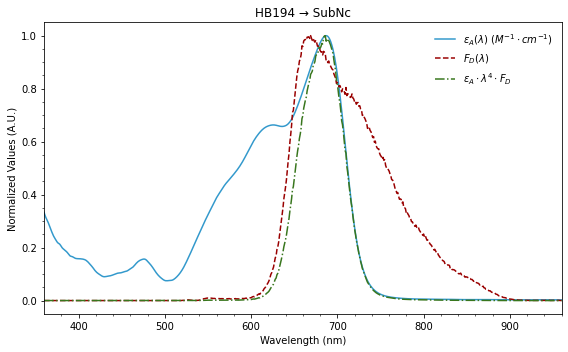

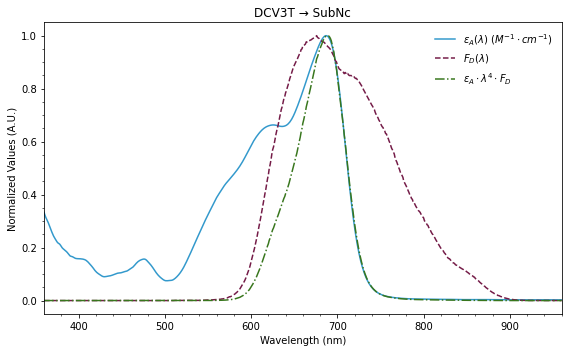

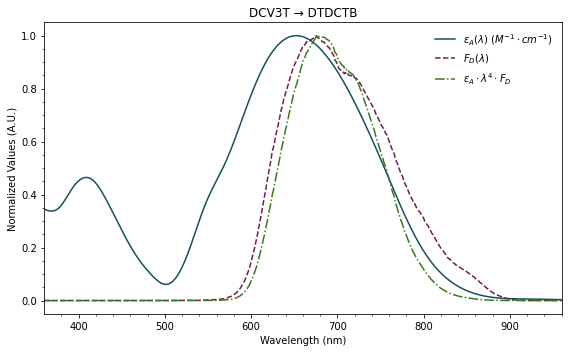

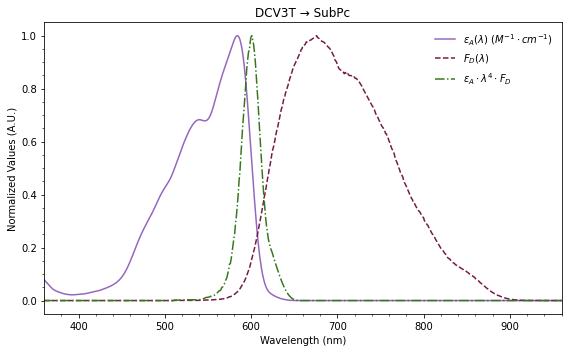

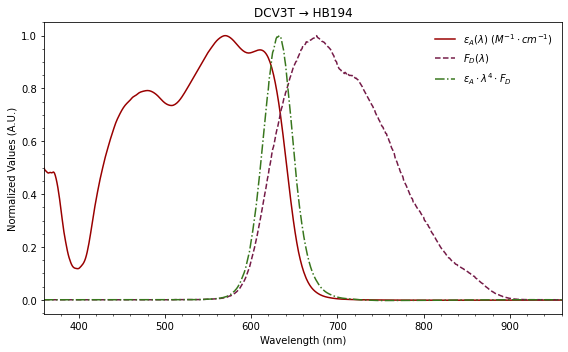

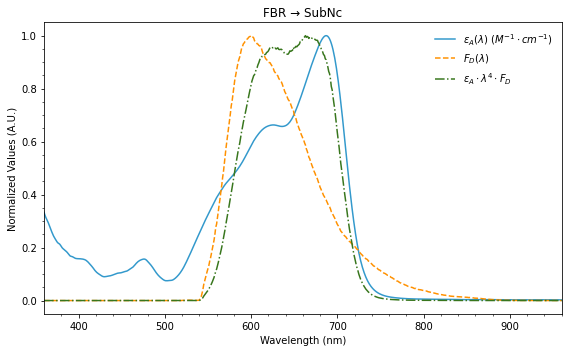

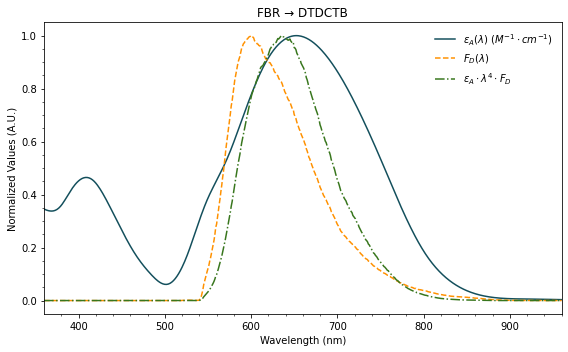

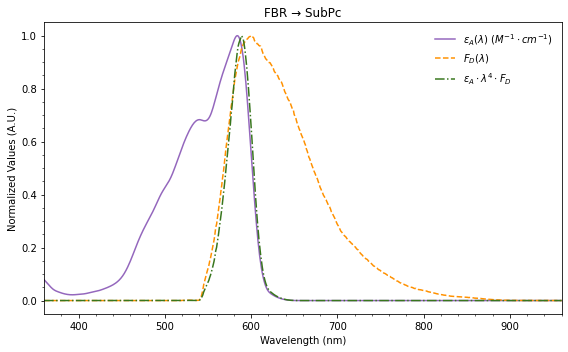


All systems processed:
   Donor Acceptor  J (L mol^-1 cm^-1 nm^4)
0  HB194    SubNc             1.443618e+16
1  DCV3T    SubNc             1.366674e+16
2  DCV3T   DTDCTB             1.092672e+16
3  DCV3T    SubPc             2.130341e+14
4  DCV3T    HB194             1.740786e+15
5    FBR    SubNc             1.362950e+16
6    FBR   DTDCTB             8.986782e+15
7    FBR    SubPc             3.375765e+15


In [49]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from scipy.integrate import simpson

# --- Load bins (all rows) ---
bins_path = "/Users/mingzhu/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Thesis Figures/Chap6/FRET_calculations/J_integral_bins.csv"
bins = pd.read_csv(bins_path)

results = []             # will collect {"Donor","Acceptor","J (...)"}
summaries = {}           # optional: {(Donor,Acceptor): per-system summary df}

# user-defined plotting window (nm)
wlmin_plot, wlmax_plot = 360, 960

for i, row in bins.iterrows():
    donor_name    = str(row["Donor"])
    acceptor_name = str(row["Acceptor"])
    pl_path       = str(row["Path_Donor_PL"])
    k_path        = str(row["Path_Acceptor_kappa"])
    Mw            = float(row["Acceptor_Mw"])
    rho           = float(row["Acceptor_rho"])
    D_color       = str(row["D_color"])
    A_color       = str(row["A_color"])

    # --- Load PL ---
    pl_raw = pd.read_csv(pl_path, delim_whitespace=True, comment="#", header=None)
    pl = pl_raw.iloc[1:, [0, 1]].copy()
    pl.columns = ["Wavelength (nm)", "Intensity (counts)"]
    wl_pl = pl["Wavelength (nm)"].to_numpy(dtype=float)
    I_pl  = pl["Intensity (counts)"].to_numpy(dtype=float)
    idx = np.argsort(wl_pl); wl_pl, I_pl = wl_pl[idx], I_pl[idx]

    # --- Load kappa ---
    kdf = pd.read_csv(k_path)
    kappa_col = [c for c in kdf.columns if c.lower().endswith("_k")][0]
    wl_k  = kdf["Wavelength (nm)"].to_numpy(dtype=float)
    kap   = kdf[kappa_col].to_numpy(dtype=float)
    idxk = np.argsort(wl_k); wl_k, kap = wl_k[idxk], kap[idxk]

    # --- AUC-normalise PL (native grid) ---
    auc_pl = np.trapz(I_pl, wl_pl)
    F_pl   = I_pl / auc_pl

    # --- Build 1-nm grid across κ span ---
    wlmin = int(np.ceil(wl_k.min()))
    wlmax = int(np.floor(wl_k.max()))
    wl_1n = np.arange(wlmin, wlmax + 1, 1, dtype=float)

    # --- Interpolate κ(λ) → 1 nm ---
    kap_1n = np.interp(wl_1n, wl_k, kap)

    # --- Interpolate F_D(λ) → 1 nm with zero outside PL span (guard points) ---
    xmin, xmax = wl_pl.min(), wl_pl.max()
    eps = 1e-6
    wl_pl_ext = np.concatenate(([xmin - eps], wl_pl, [xmax + eps]))
    F_pl_ext  = np.concatenate(([0.0],       F_pl,  [0.0]))
    F_1n      = np.interp(wl_1n, wl_pl_ext, F_pl_ext)

    # --- α(λ) and ε(λ) (NO ln(10)) ---
    alpha_1n = (4.0 * math.pi * kap_1n) / (wl_1n * 1e-7)         # cm^-1
    eps_1n   = (alpha_1n * Mw) / (rho * 1000.0)                  # L mol^-1 cm^-1

    # --- Integrand and J ---
    integrand = eps_1n * F_1n * (wl_1n ** 4)                     # L mol^-1 cm^-1 nm^3
   #J = float(np.trapz(integrand, wl_1n))
    J = float(simpson(integrand, x=wl_1n))# L mol^-1 cm^-1 nm^4

    # --- Store result row ---
    results.append({"Donor": donor_name, "Acceptor": acceptor_name, "J (L mol^-1 cm^-1 nm^4)": J})

    # --- Optional per-system summary table (handy to inspect/save later) ---
    summary = pd.DataFrame({
        "Wavelength (nm)": wl_1n,
        "F_D_norm(1/nm)": F_1n,
        "kappa(unitless)": kap_1n,
        "alpha(cm^-1)": alpha_1n,
        "epsilon(L mol^-1 cm^-1)": eps_1n,
        "eps*F*lam^4 (L mol^-1 cm^-1 nm^3)": integrand
    })
    summaries[(donor_name, acceptor_name)] = summary

    # --- Combined normalized overlap plot for this system (uses your colors) ---
    mask = (wl_1n >= wlmin_plot) & (wl_1n <= wlmax_plot)
    wl_plot  = wl_1n[mask]
    e_plot   = eps_1n[mask]; e_plot /= e_plot.max() if e_plot.max() > 0 else 1.0
    f_plot   = F_1n[mask];   f_plot /= f_plot.max() if f_plot.max() > 0 else 1.0
    g_plot   = integrand[mask]; g_plot /= g_plot.max() if g_plot.max() > 0 else 1.0

    plt.figure(figsize=(8,5))
    plt.plot(wl_plot, e_plot,  '-',  color=A_color, label=r'$\epsilon_A(\lambda)$ ($M^{-1}\cdot cm^{-1}$)')
    plt.plot(wl_plot, f_plot,  '--', color=D_color, label=r'$F_D(\lambda)$')
    plt.plot(wl_plot, g_plot,  '-.', color="#38761d", label=r'$\epsilon_A \cdot \lambda^4 \cdot F_D$ ')
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Normalized Values (A.U.)")
    plt.title(f"{donor_name} → {acceptor_name}")
    plt.legend(frameon=False)
    plt.minorticks_on()
    plt.xlim(wlmin_plot, wlmax_plot)
    plt.tight_layout()
    plt.show()

# --- All systems summary ---
results_df = pd.DataFrame(results)
print("\nAll systems processed:")
print(results_df)

# Optional save:
# results_df.to_csv("J_integral_summary.csv", index=False)
# For any detailed per-system table:
# summaries[("DonorName","AcceptorName")].to_csv("summary_Donor_Acceptor.csv", index=False)


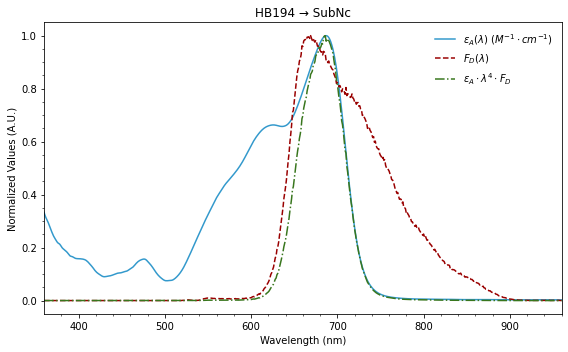

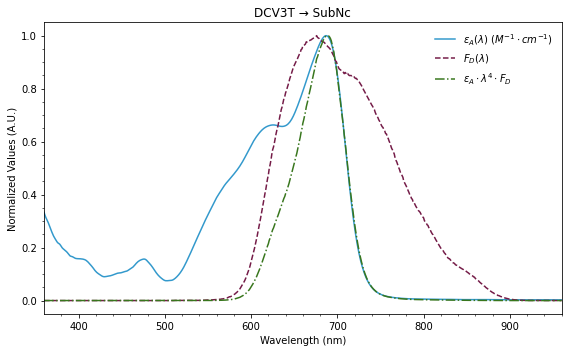

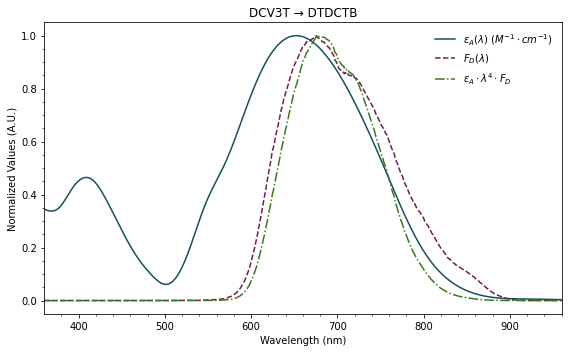

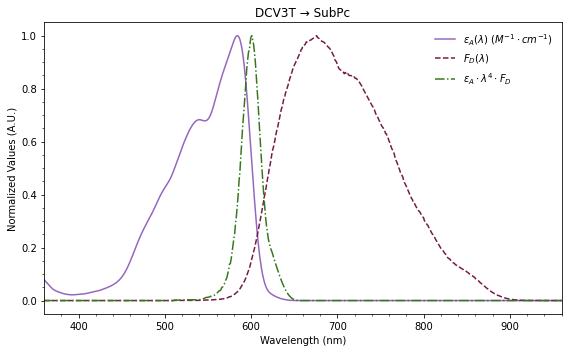

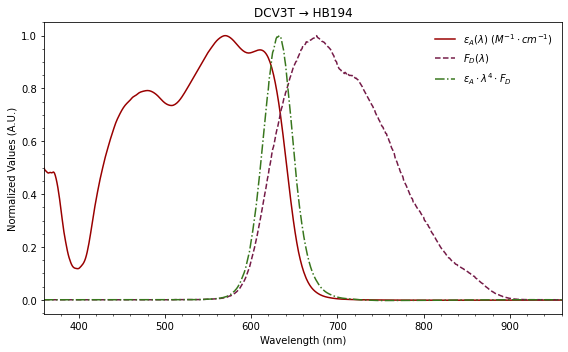

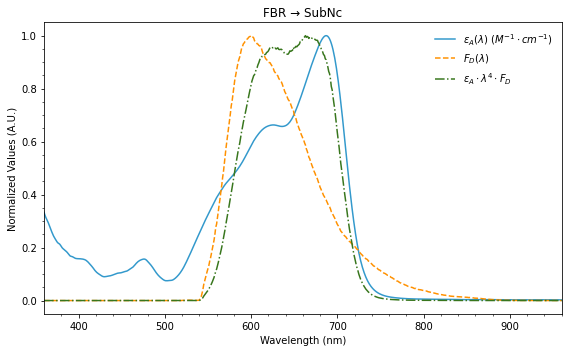

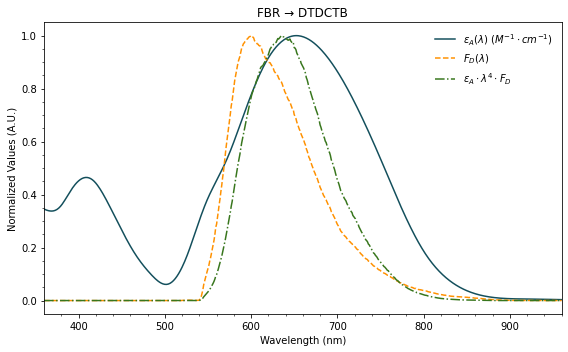

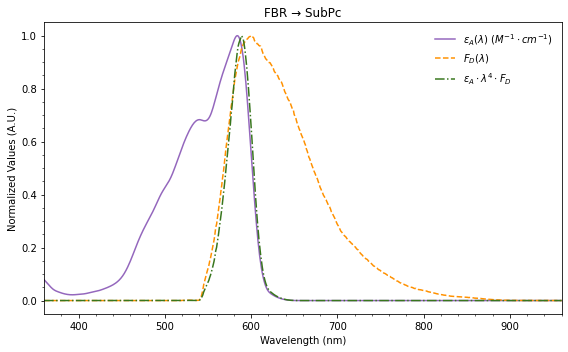


All systems processed:
   Donor Acceptor  J (L mol^-1 cm^-1 nm^4)
0  HB194    SubNc             1.444071e+16
1  DCV3T    SubNc             1.366749e+16
2  DCV3T   DTDCTB             1.092671e+16
3  DCV3T    SubPc             2.130266e+14
4  DCV3T    HB194             1.740810e+15
5    FBR    SubNc             1.362780e+16
6    FBR   DTDCTB             8.985576e+15
7    FBR    SubPc             3.374764e+15


In [51]:
import os
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

# --- User options for saving figures -----------------------------------------
save_figs   = True              # <- set to False to disable saving
fig_format  = "pdf"             # 'pdf' as requested (vector). You can switch to 'png' if needed.
fig_dpi     = 600               # DPI setting (mostly relevant for raster formats; still accepted for pdf)
out_dir     = "/Users/mingzhu/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Thesis Figures/Chap6/FRET_calculations"       # output folder for figures
os.makedirs(out_dir, exist_ok=True)

# Tiny filename sanitizer (keeps alnum, dot, underscore, hyphen; spaces -> underscores)
def _slug(s):
    return "".join(c if c.isalnum() or c in "._- " else "_" for c in str(s)).replace(" ", "_")

# --- Load bins (all rows) -----------------------------------------------------
bins_path = "/Users/mingzhu/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Thesis Figures/Chap6/FRET_calculations/J_integral_bins.csv"
bins = pd.read_csv(bins_path)

results = []             # will collect {"Donor","Acceptor","J (...)"}
summaries = {}           # optional: {(Donor,Acceptor): per-system summary df}

# user-defined plotting window (nm)
wlmin_plot, wlmax_plot = 360, 960

for i, row in bins.iterrows():
    donor_name    = str(row["Donor"])
    acceptor_name = str(row["Acceptor"])
    pl_path       = str(row["Path_Donor_PL"])
    k_path        = str(row["Path_Acceptor_kappa"])
    Mw            = float(row["Acceptor_Mw"])
    rho           = float(row["Acceptor_rho"])
    D_color       = str(row["D_color"])
    A_color       = str(row["A_color"])

    # --- Load PL ---
    pl_raw = pd.read_csv(pl_path, delim_whitespace=True, comment="#", header=None)
    pl = pl_raw.iloc[1:, [0, 1]].copy()
    pl.columns = ["Wavelength (nm)", "Intensity (counts)"]
    wl_pl = pl["Wavelength (nm)"].to_numpy(dtype=float)
    I_pl  = pl["Intensity (counts)"].to_numpy(dtype=float)
    idx = np.argsort(wl_pl); wl_pl, I_pl = wl_pl[idx], I_pl[idx]

    # --- Load kappa ---
    kdf = pd.read_csv(k_path)
    kappa_col = [c for c in kdf.columns if c.lower().endswith("_k")][0]
    wl_k  = kdf["Wavelength (nm)"].to_numpy(dtype=float)
    kap   = kdf[kappa_col].to_numpy(dtype=float)
    idxk = np.argsort(wl_k); wl_k, kap = wl_k[idxk], kap[idxk]

    # --- AUC-normalise PL (native grid) ---
    auc_pl = np.trapz(I_pl, wl_pl)
    F_pl   = I_pl / auc_pl

    # --- Build 1-nm grid across κ span ---
    wlmin = int(np.ceil(wl_k.min()))
    wlmax = int(np.floor(wl_k.max()))
    wl_1n = np.arange(wlmin, wlmax + 1, 1, dtype=float)

    # --- Interpolate κ(λ) → 1 nm ---
    kap_1n = np.interp(wl_1n, wl_k, kap)

    # --- Interpolate F_D(λ) → 1 nm with zero outside PL span (guard points) ---
    xmin, xmax = wl_pl.min(), wl_pl.max()
    eps = 1e-6
    wl_pl_ext = np.concatenate(([xmin - eps], wl_pl, [xmax + eps]))
    F_pl_ext  = np.concatenate(([0.0],       F_pl,  [0.0]))
    F_1n      = np.interp(wl_1n, wl_pl_ext, F_pl_ext)

    # --- α(λ) and ε(λ) (NO ln(10)) ---
    alpha_1n = (4.0 * math.pi * kap_1n) / (wl_1n * 1e-7)         # cm^-1
    eps_1n   = (alpha_1n * Mw) / (rho * 1000.0)                  # L mol^-1 cm^-1

    # --- Integrand and J ---
    integrand = eps_1n * F_1n * (wl_1n ** 4)                     # L mol^-1 cm^-1 nm^3

    # If you switched to SciPy, you could do:
    # from scipy.integrate import simpson
    # J = float(simpson(integrand, x=wl_1n))
    J = float(np.trapz(integrand, wl_1n))                        # L mol^-1 cm^-1 nm^4

    # --- Store result row ---
    results.append({"Donor": donor_name, "Acceptor": acceptor_name, "J (L mol^-1 cm^-1 nm^4)": J})

    # --- Optional per-system summary table (handy to inspect/save later) ---
    summary = pd.DataFrame({
        "Wavelength (nm)": wl_1n,
        "F_D_norm(1/nm)": F_1n,
        "kappa(unitless)": kap_1n,
        "alpha(cm^-1)": alpha_1n,
        "epsilon(L mol^-1 cm^-1)": eps_1n,
        "eps*F*lam^4 (L mol^-1 cm^-1 nm^3)": integrand
    })
    summaries[(donor_name, acceptor_name)] = summary

    # --- Combined normalized overlap plot for this system (uses your colors) ---
    mask = (wl_1n >= wlmin_plot) & (wl_1n <= wlmax_plot)
    wl_plot  = wl_1n[mask]
    e_plot   = eps_1n[mask]; e_plot /= e_plot.max() if e_plot.max() > 0 else 1.0
    f_plot   = F_1n[mask];   f_plot /= f_plot.max() if f_plot.max() > 0 else 1.0
    g_plot   = integrand[mask]; g_plot /= g_plot.max() if g_plot.max() > 0 else 1.0

    plt.figure(figsize=(8,5))
    plt.plot(wl_plot, e_plot,  '-',  color=A_color, label=r'$\epsilon_A(\lambda)$ ($M^{-1}\cdot cm^{-1}$)')
    plt.plot(wl_plot, f_plot,  '--', color=D_color, label=r'$F_D(\lambda)$')
    plt.plot(wl_plot, g_plot,  '-.', color="#38761d", label=r'$\epsilon_A \cdot \lambda^4 \cdot F_D$')
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Normalized Values (A.U.)")
    plt.title(f"{donor_name} → {acceptor_name}")
    plt.legend(frameon=False)
    plt.minorticks_on()
    plt.xlim(wlmin_plot, wlmax_plot)
    plt.tight_layout()

    # --- Save figure as PDF if enabled ---------------------------------------
    if save_figs:
        fname = f"overlap_{_slug(donor_name)}__to__{_slug(acceptor_name)}.{fig_format}"
        plt.savefig(os.path.join(out_dir, fname), format=fig_format, dpi=fig_dpi, bbox_inches="tight")
    plt.show()

# --- All systems summary ------------------------------------------------------
results_df = pd.DataFrame(results)
print("\nAll systems processed:")
print(results_df)

# Optional save:
results_df.to_csv("/Users/mingzhu/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Thesis Figures/Chap6/FRET_calculations/J_integral_summary.csv", index=False)
# For any detailed per-system table:
# summaries[("DonorName","AcceptorName")].to_csv("summary_Donor_Acceptor.csv", index=False)
